### Setup and Clean

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.style.use("seaborn-v0_8")

DATA_PATH = Path("online_retail_II.xlsx")
raw = pd.read_excel(DATA_PATH)

raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
df = raw.copy()

# Standardize column names
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
)

# Normalize key fields
df["Invoice"] = df["Invoice"].astype(str).str.strip()
df["StockCode"] = df["StockCode"].astype(str).str.strip()
df["Description"] = df["Description"].astype("string").str.strip()
df["Country"] = df["Country"].astype(str).str.strip()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Customer_ID may be named Customer_ID already after normalization, but handle both safely
if "Customer_ID" not in df.columns and "Customer_ID" in raw.columns:
    df["Customer_ID"] = pd.to_numeric(raw["Customer ID"], errors="coerce")
elif "Customer_ID" in df.columns:
    df["Customer_ID"] = pd.to_numeric(df["Customer_ID"], errors="coerce")
else:
    # If the normalized name is Customer_ID from "Customer ID"
    if "Customer_ID" not in df.columns and "Customer_ID" in df.columns:
        df["Customer_ID"] = pd.to_numeric(df["Customer_ID"], errors="coerce")

# Flags (kept for later analysis even if we filter purchases)
df["IsCancellationInvoice"] = df["Invoice"].str.startswith("C", na=False)
df["IsReturnLine"] = df["Quantity"] < 0

before = len(df)

# Minimal validity
df = df.dropna(subset=["InvoiceDate", "Invoice", "StockCode"])
df = df[df["Quantity"].notna() & df["Price"].notna()]

# Purchase-only filter for mining
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

after = len(df)
before, after, before - after


(525461, 511566, 13895)

In [3]:
# Derived fields used across EDA + methods
df["TotalPrice"] = df["Quantity"] * df["Price"]
df["Date"] = df["InvoiceDate"].dt.date
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["Hour"] = df["InvoiceDate"].dt.hour
df["Weekday"] = df["InvoiceDate"].dt.day_name()

audit = {
    "rows_raw": len(raw),
    "rows_clean_purchase_only": len(df),
    "unique_invoices": df["Invoice"].nunique(),
    "unique_products": df["StockCode"].nunique(),
    "unique_customers_nonnull": df["Customer_ID"].nunique(dropna=True),
    "countries": df["Country"].nunique(),
    "date_min": df["InvoiceDate"].min(),
    "date_max": df["InvoiceDate"].max(),
}
audit


{'rows_raw': 525461,
 'rows_clean_purchase_only': 511566,
 'unique_invoices': 20952,
 'unique_products': 4250,
 'unique_customers_nonnull': 4312,
 'countries': 40,
 'date_min': Timestamp('2009-12-01 07:45:00'),
 'date_max': Timestamp('2010-12-09 20:01:00')}

## Checkpoint 2

### Additional EDA

Basket size distribution
: Apriori/FP-growth runtime depends heavily on basket sizes and item universe.

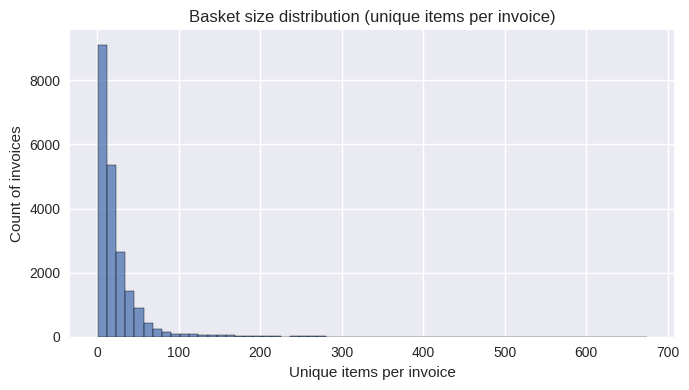

In [4]:
basket_sizes = df.groupby("Invoice")["StockCode"].nunique().sort_values(ascending=False)

basket_sizes.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
plt.figure(figsize=(7,4))
sns.histplot(basket_sizes, bins=60)
plt.title("Basket size distribution (unique items per invoice)")
plt.xlabel("Unique items per invoice")
plt.ylabel("Count of invoices")
plt.tight_layout()
plt.show()


Most invoices contain a small number of unique items, while a small fraction of invoices are very large baskets (the long right tail). This is typical in retail: many customers buy a few items, but some invoices represent bulk/wholesale-like purchases or large seasonal orders. The heavy tail matters because frequent itemset mining runtime grows quickly with basket size—large baskets generate many candidate subsets.

Country concentration: If one country dominates, rules may reflect that market; we may optionally focus on that country for stability.

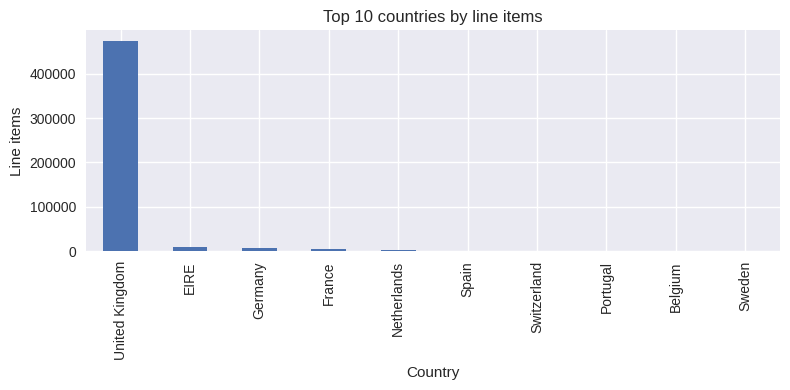

In [5]:
country_counts = df["Country"].value_counts()
country_counts.head(10)
plt.figure(figsize=(8,4))
country_counts.head(10).plot(kind="bar")
plt.title("Top 10 countries by line items")
plt.ylabel("Line items")
plt.tight_layout()
plt.show()


The country bar chart shows the dataset is dominated by the United Kingdom, with other countries contributing much smaller shares. This means that “global” association rules or customer segments will largely reflect UK purchasing behavior, and cross-country differences may be washed out unless you explicitly stratify by country.

Customer coverage for sequential mining feasibility: Sequential Mining needs customer sequences; we must know how many customers have enough purchases.

In [6]:
cust_invoice_counts = (
    df.dropna(subset=["Customer_ID"])
      .groupby("Customer_ID")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
)

cust_invoice_counts.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])


,Invoice
count,4312.000000
mean,4.455705
std,8.170213
min,1.000000
50%,2.000000
75%,5.000000
90%,9.000000
95%,13.000000
99%,31.000000
max,205.000000


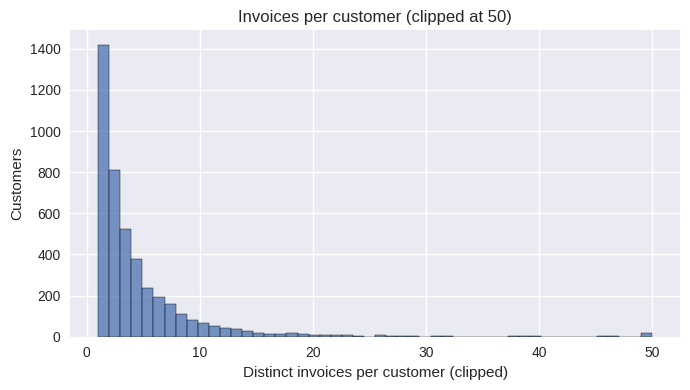

In [7]:
plt.figure(figsize=(7,4))
sns.histplot(np.clip(cust_invoice_counts, 0, 50), bins=50)
plt.title("Invoices per customer (clipped at 50)")
plt.xlabel("Distinct invoices per customer (clipped)")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()


The invoice-per-customer distribution is strongly skewed: the median customer has only a small number of invoices, while a small subset of customers have many repeat purchases (up to very large counts). This is important because sequential pattern mining needs enough events per customer to reveal meaningful orderings; customers with 1–2 invoices contribute little to multi-step sequences.

## Research Questions

| RQ  | Task type                                   | Course vs external | Algorithms                                   | Key metrics / evaluation                                      |
|-----|---------------------------------------------|--------------------|-----------------------------------------------|---------------------------------------------------------------|
| How do the top association rules change as we vary minimum support and minimum confidence, and does lift filter out “popular-item” illusions better than confidence alone? | Frequent itemset mining + association rules | Course             | Apriori + rule generation                     | Support, confidence, lift; rule redundancy/diversity         |
| Do customers cluster into distinct segments based on Recency–Frequency–Monetary (RFM) behavior, and are the clusters stable across time windows? | Customer segmentation                       | Course             | KMeans clustering on RFM features             | Silhouette; cluster interpretability (R/F/M profiles)        |
| hen we treat each customer’s purchases as a time-ordered sequence of baskets, what sequential patterns (e.g., A → B) appear that are not captured by unordered association rules? | Sequential pattern mining                   | External           | PrefixSpan (open-source Python package)       | Sequential support; novelty vs unordered itemsets; pattern length distribution |

### RQ 1 - Association Rules via Apriori

How do frequent itemsets and association rules change as minimum support and confidence thresholds vary, and does lift better identify non‑trivial associations than confidence alone?

#### Motivation
Retailers often rely on association rules to drive recommendations and promotions. However, in long‑tailed datasets, confidence alone can be misleading, since popular items inflate conditional probabilities. This raises a practical question: which rules are genuinely informative versus artifacts of popularity.

EDA revealed:

1. A small fraction of products account for a large share of invoices

2. Many products appear in fewer than 10 invoices

3. Basket sizes are moderate, making Apriori feasible with filtering


#### Methodology
* Convert each invoice into a set of purchased products

* Apply Apriori to mine frequent itemsets

* Generate association rules

* Compare rules ranked by Confidence,Lift etc.

*  Control combinatorial explosion by:

    * Restricting to top‑N frequent products

    * Using moderate support thresholds


#### Evaluation Criteria
* Support — prevalence of itemsets

* Confidence — conditional probability

* Lift — deviation from independence

* Rule diversity — avoid redundant rules with identical consequents


#### Feasibility & Risks
* Feasible: Basket sizes are small; Apriori is tractable with filtering

* Risk: Low support thresholds cause rule explosion

* Mitigation: Parameter sweeps + item filtering

In [13]:
## Example sanity check of the library
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

toy_baskets = [
    ["A", "B", "C"],
    ["A", "B"],
    ["A", "C"],
    ["B", "C"],
    ["A", "B", "C"]
]

te = TransactionEncoder()
X = te.fit(toy_baskets).transform(toy_baskets)
df_toy = pd.DataFrame(X, columns=te.columns_)

freq = apriori(df_toy, min_support=0.6, use_colnames=True)
rules = association_rules(freq, metric="confidence", min_threshold=0.7)

freq, rules


(   support itemsets
 0      0.8      (A)
 1      0.8      (B)
 2      0.8      (C)
 3      0.6   (A, B)
 4      0.6   (C, A)
 5      0.6   (C, B),
   antecedents consequents  antecedent support  consequent support  support  \
 0         (A)         (B)                 0.8                 0.8      0.6   
 1         (B)         (A)                 0.8                 0.8      0.6   
 2         (C)         (A)                 0.8                 0.8      0.6   
 3         (A)         (C)                 0.8                 0.8      0.6   
 4         (C)         (B)                 0.8                 0.8      0.6   
 5         (B)         (C)                 0.8                 0.8      0.6   
 
    confidence    lift  representativity  leverage  conviction  zhangs_metric  \
 0        0.75  0.9375               1.0     -0.04         0.8          -0.25   
 1        0.75  0.9375               1.0     -0.04         0.8          -0.25   
 2        0.75  0.9375               1.0     -0.04    

In [24]:
supports = dict(zip(freq["itemsets"].astype(str), freq["support"]))
assert supports["frozenset({'A'})"] == 0.8
assert supports["frozenset({'A', 'B'})"] == 0.6

### RQ 2 - Customer Segmentation via Clustering

Do customers form distinct behavioral segments based on recency, frequency, and monetary value, and how interpretable are these clusters?

#### Motivation
Not all customers behave the same. Segmenting customers enables targeted marketing, churn analysis, and personalization. Transactional data naturally supports behavior‑based clustering.

EDA revealed:

1. Thousands of customers with multiple invoices

2. Large variance in purchase frequency and spend


#### Methodology
* Construct RFM features:

    * Recency: days since last purchase

    * Frequency: number of invoices

    * Monetary: total spend

* Standardize features

* Apply KMeans clustering

* Sweep number of clusters 𝑘


#### Evaluation Criteria
* Silhouette score — internal cluster quality

* Cluster interpretability — median RFM profiles

* Stability across k


#### Feasibility & Risks
* Feasible: RFM is low‑dimensional and well‑studied

* Risk: KMeans assumes spherical clusters

* Mitigation: Interpretability checks + silhouette validation or try out DBScan

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np

X = np.array([
    [10, 2, 100],
    [12, 2, 120],
    [200, 20, 2000],
    [210, 22, 2100]
])

X_scaled = StandardScaler().fit_transform(X)
labels = KMeans(n_clusters=2, random_state=0).fit_predict(X_scaled)

silhouette_score(X_scaled, labels)


np.float64(0.9588112958919908)

### RQ 3 - Sequential Pattern Mining (External)

Do sequential purchase patterns reveal structure that unordered frequent itemsets miss?

#### Motivation
Association rules ignore order. In retail, what customers buy next often matters more than co‑occurrence. Sequential patterns can reveal lifecycle behaviors invisible to unordered mining.


EDA revealed:

1. Timestamped invoices

2. Repeat customers with long purchase histories

3. Natural customer‑level sequences


#### Methodology
* Group invoices by customer

* Order baskets temporally

* Apply PrefixSpan to mine frequent sequences

* Restrict to customers with sufficient history


#### Evaluation Criteria
* Sequential support

* Pattern length distribution

* Novelty vs Apriori rules


#### Feasibility & Risks
* Feasible: PrefixSpan has a lightweight Python implementation

* Risk: Sparse sequences

* Mitigation: Filter to frequent items and repeat customers

In [15]:
!pip install prefixspan

In [23]:
from prefixspan import PrefixSpan

toy_sequences = [
    [("A", "B"), ("C",)],
    [("A",), ("B",), ("C",)],
    [("A",), ("C",)],
    [("B",), ("C",)]
]

ps = PrefixSpan(toy_sequences)

patterns = ps.frequent(2)
print(patterns[:10])

[(4, [('C',)]), (2, [('A',)]), (2, [('A',), ('C',)]), (2, [('B',)]), (2, [('B',), ('C',)])]


On my honor, I declare the following resources were used.

1. Collaborators:
    - None

2. Web Sources:
    - UCI Machine Learning Repository — Online Retail II dataset documentation: https://archive.ics.uci.edu/dataset/502/online+retail+ii
    - mlxtend documentation — Apriori and association rules: https://rasbt.github.io/mlxtend/
    - scikit-learn documentation — KMeans and silhouette score: https://scikit-learn.org/stable/
    - prefixspan Python package (PyPI / docs): https://pypi.org/project/prefixspan/

3. AI Tools:
    - ChatGPT: used selectively to refine research question wording, improve clarity of explanations, and sanity-check feasibility planning.
    - Perplexity: to find functions and library that supports my usecase.

4. Citations:
    - None
